In [37]:
import os
import pydicom
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [3]:
test_directory = os.path.join("..", "data", "PANCREAS_2", "PANCREAS_2", "49_01", "20191106")

valid_files = [f for f in os.listdir(test_directory) if not f.startswith(".")]
file_path = os.path.join(test_directory, valid_files[0])

print(f"Testing segmentation on: {os.path.basename(file_path)}")

Testing segmentation on: 1.3.6.1.4.1.14519.5.2.1.9688.9989.206846852338263339128528968856


In [ ]:
# dcmread unpacks the dicom images containing headers, patient data and raw scanner info
dataset = pydicom.dcmread(file_path)
# takes raw compressed binary data from dicom file and transltes it to a 2d numpy array of pixel values
image_rgb = dataset.pixel_array

In [42]:
# Define the threshold for "white"
# Color values range from 0 black to 255 white
# 200 is standard first try but 230 seems to work even better as white contour is very well defined
color_threshold = 230

In [43]:
red_channel = image_rgb[:, :, 0]
green_channel = image_rgb[:, :, 1]
blue_channel = image_rgb[:, :, 2]

is_red_bright = red_channel > color_threshold
is_green_bright = green_channel > color_threshold
is_blue_bright = blue_channel > color_threshold

In [44]:
# A pixel must be bright in Red AND Green AND Blue to be considered white
white_pixels_mask = is_red_bright & is_green_bright & is_blue_bright

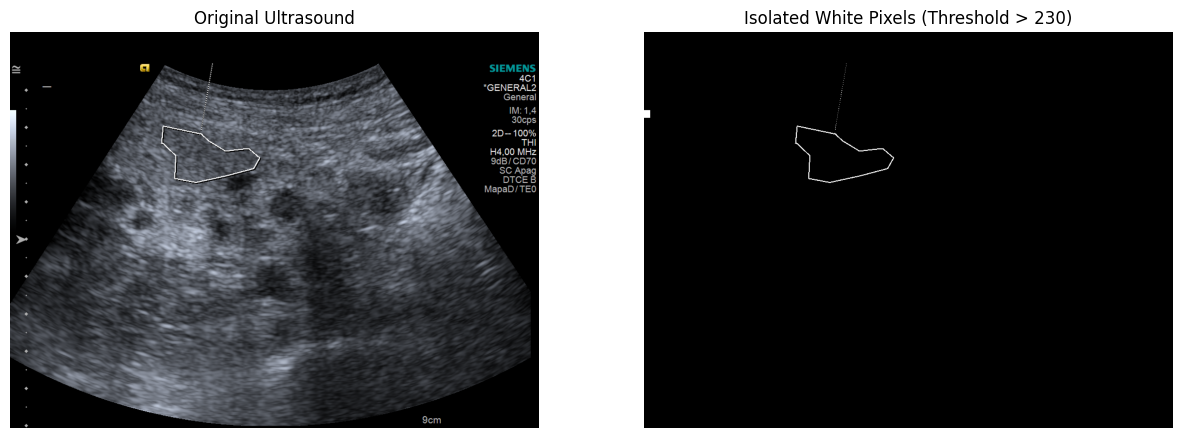

In [45]:
# Visualize the results
plt.figure(figsize=(15, 7))

# Plot Original
plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Ultrasound")
plt.axis("off")

# Plot the Black and White Mask
plt.subplot(1, 2, 2)
plt.imshow(white_pixels_mask, cmap="gray")
plt.title(f"Isolated White Pixels (Threshold > {color_threshold})")
plt.axis("off")

plt.show()

In [46]:
# Convert the boolean mask (True/False) to an 8-bit image (255 for white, 0 for black)
# OpenCV requires this format
white_mask_8bit = (white_pixels_mask * 255).astype(np.uint8)

# Label every separate white object it finds with cv2
# function groups connected white pixels into islands and calculates their area
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(white_mask_8bit, connectivity=8)

In [47]:
largest_label = 1
max_area = 0

# Loop through all found islands to find the one with the biggest area
for i in range(1, num_labels):
    # Get the area of the current island
    area = stats[i, cv2.CC_STAT_AREA]
    
    # If bigger than our current max remember this label
    if area > max_area:
        max_area = area
        largest_label = i

# Create a clean black image of the exact same size
clean_contour_mask = np.zeros_like(white_mask_8bit)

# Paint ONLY the largest island white on our new clean black image
clean_contour_mask[labels == largest_label] = 255

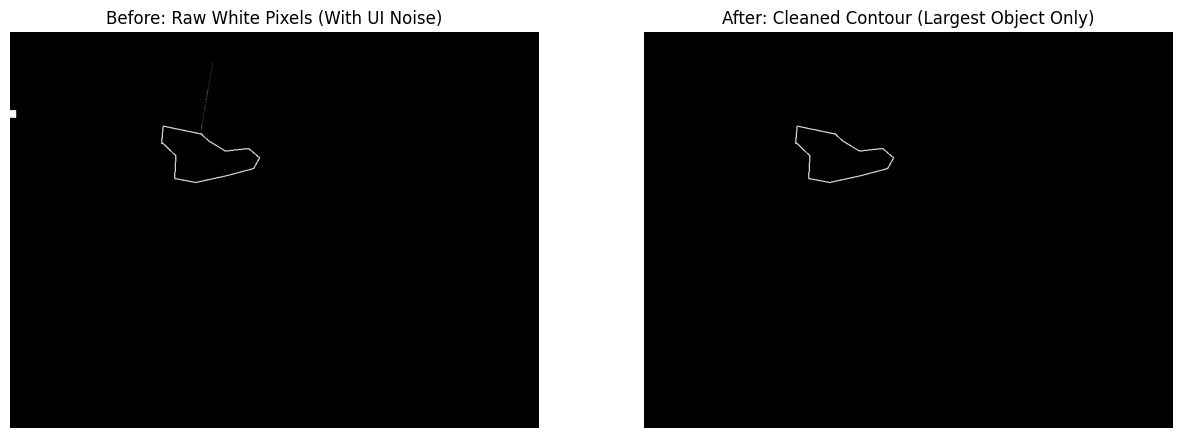

In [48]:
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.imshow(white_mask_8bit, cmap="gray")
plt.title("Before: Raw White Pixels with UI Noise")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(clean_contour_mask, cmap="gray")
plt.title("After: Cleaned Contour (Largest Object Only)")
plt.axis("off")

plt.show()

In [49]:
# Trace boundary of white loop
# RETR_EXTERNAL means we only care about the outermost loop
contours, hierarchy = cv2.findContours(clean_contour_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Create new blank same-size black image
filled_mask = np.zeros_like(clean_contour_mask)

# Draw the contour and fill it with white
# thickness=cv2.FILLED equal to -1 used to fill in contour
cv2.drawContours(filled_mask, contours, contourIdx=-1, color=255, thickness=cv2.FILLED)

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

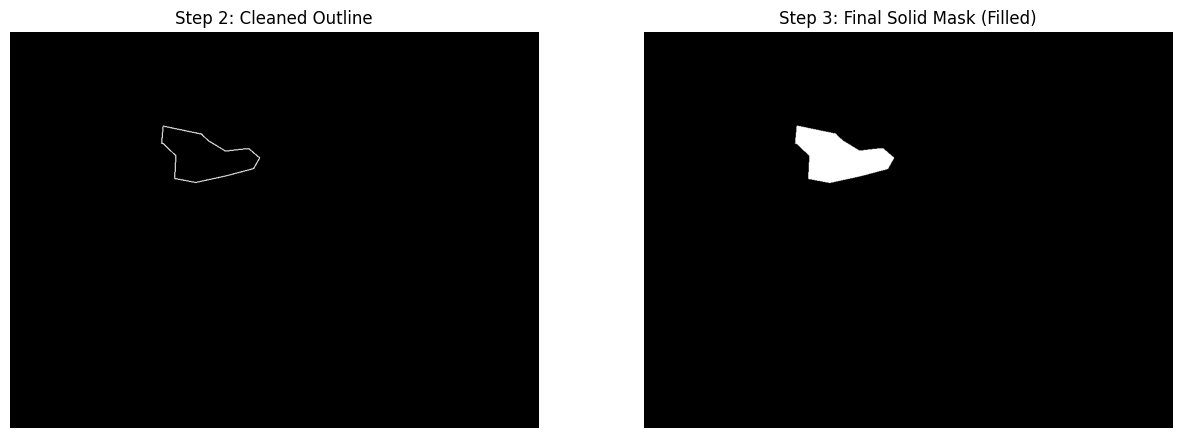

In [50]:
# Visualize the Final Mask
plt.figure(figsize=(15, 7))

# Plot the outline (Before)
plt.subplot(1, 2, 1)
plt.imshow(clean_contour_mask, cmap="gray")
plt.title("Step 2: Cleaned Outline")
plt.axis("off")

# Plot the filled solid mask (After)
plt.subplot(1, 2, 2)
plt.imshow(filled_mask, cmap="gray")
plt.title("Step 3: Final Solid Mask (Filled)")
plt.axis("off")

plt.show()

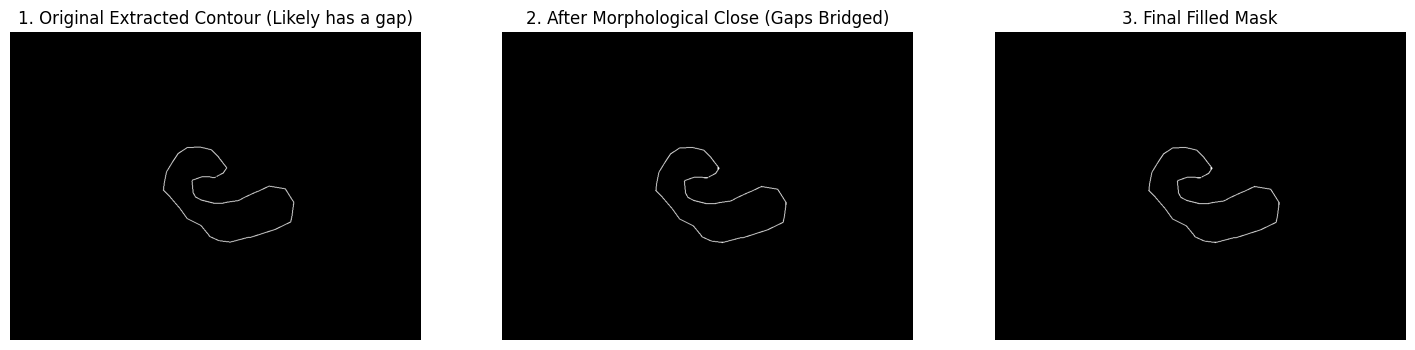

In [64]:
import os
import pydicom
import numpy as np
import cv2
import matplotlib.pyplot as plt

# 1. Target the problematic image directly
test_directory = os.path.join("..", "data", "PANCREAS_2", "PANCREAS_2", "03_01")
date_folders = [f for f in os.listdir(test_directory) if not f.startswith(".")]
date_path = os.path.join(test_directory, date_folders[0])
valid_files = [f for f in os.listdir(date_path) if not f.startswith(".")]
file_path = os.path.join(date_path, valid_files[0])

# 2. Extract Contour (Same as before)
dataset = pydicom.dcmread(file_path)
image_rgb = dataset.pixel_array
color_threshold = 200

white_mask = (image_rgb[:, :, 0] > color_threshold) & \
             (image_rgb[:, :, 1] > color_threshold) & \
             (image_rgb[:, :, 2] > color_threshold)
white_mask_8bit = (white_mask * 255).astype(np.uint8)

num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(white_mask_8bit, connectivity=8)
largest_label = 1
max_area = 0
for i in range(1, num_labels):
    area = stats[i, cv2.CC_STAT_AREA]
    if area > max_area:
        max_area = area
        largest_label = i
        
clean_contour_mask = np.zeros_like(white_mask_8bit)
clean_contour_mask[labels == largest_label] = 255

# --- THE INVESTIGATION: MORPHOLOGICAL CLOSING ---
# We define a 5x5 pixel "brush" (kernel)
kernel = np.ones((10, 10), np.uint8)

# We close the gaps: Dilate then Erode
closed_contour_mask = cv2.morphologyEx(clean_contour_mask, cv2.MORPH_CLOSE, kernel)

# --- ATTEMPT TO FILL ---
contours, _ = cv2.findContours(closed_contour_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
filled_mask = np.zeros_like(closed_contour_mask)
cv2.drawContours(filled_mask, contours, -1, color=255, thickness=cv2.FILLED)

# --- VISUALIZE THE DIFFERENCE ---
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(clean_contour_mask, cmap="gray")
plt.title("1. Original Extracted Contour (Likely has a gap)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(closed_contour_mask, cmap="gray")
plt.title("2. After Morphological Close (Gaps Bridged)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(filled_mask, cmap="gray")
plt.title("3. Final Filled Mask")
plt.axis("off")

plt.show()

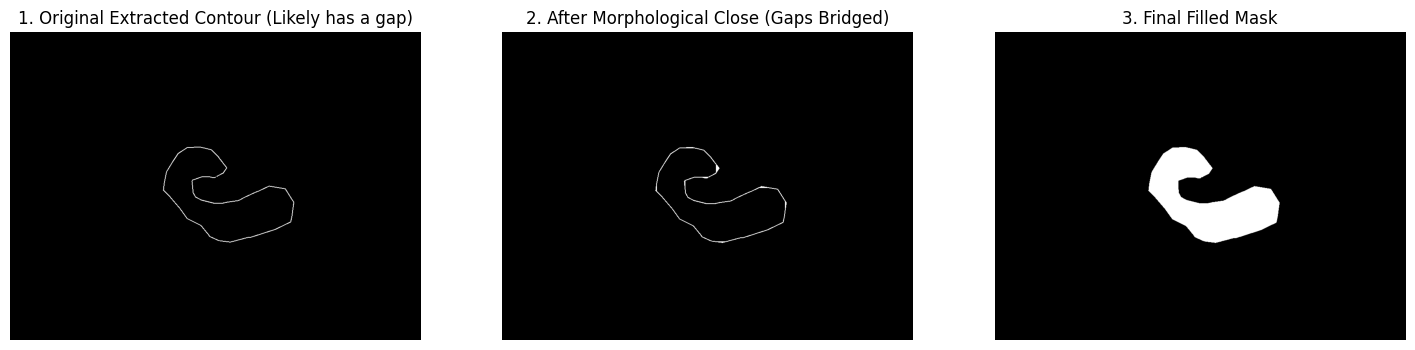

In [65]:
import os
import pydicom
import numpy as np
import cv2
import matplotlib.pyplot as plt

# 1. Target the problematic image directly
test_directory = os.path.join("..", "data", "PANCREAS_2", "PANCREAS_2", "03_01")
date_folders = [f for f in os.listdir(test_directory) if not f.startswith(".")]
date_path = os.path.join(test_directory, date_folders[0])
valid_files = [f for f in os.listdir(date_path) if not f.startswith(".")]
file_path = os.path.join(date_path, valid_files[0])

# 2. Extract Contour (Same as before)
dataset = pydicom.dcmread(file_path)
image_rgb = dataset.pixel_array
color_threshold = 200

white_mask = (image_rgb[:, :, 0] > color_threshold) & \
             (image_rgb[:, :, 1] > color_threshold) & \
             (image_rgb[:, :, 2] > color_threshold)
white_mask_8bit = (white_mask * 255).astype(np.uint8)

num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(white_mask_8bit, connectivity=8)
largest_label = 1
max_area = 0
for i in range(1, num_labels):
    area = stats[i, cv2.CC_STAT_AREA]
    if area > max_area:
        max_area = area
        largest_label = i
        
clean_contour_mask = np.zeros_like(white_mask_8bit)
clean_contour_mask[labels == largest_label] = 255

# --- THE INVESTIGATION: MORPHOLOGICAL CLOSING ---
# We define a 5x5 pixel "brush" (kernel)
kernel = np.ones((20, 20), np.uint8)

# We close the gaps: Dilate then Erode
closed_contour_mask = cv2.morphologyEx(clean_contour_mask, cv2.MORPH_CLOSE, kernel)

# --- ATTEMPT TO FILL ---
contours, _ = cv2.findContours(closed_contour_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
filled_mask = np.zeros_like(closed_contour_mask)
cv2.drawContours(filled_mask, contours, -1, color=255, thickness=cv2.FILLED)

# --- VISUALIZE THE DIFFERENCE ---
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(clean_contour_mask, cmap="gray")
plt.title("1. Original Extracted Contour (Likely has a gap)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(closed_contour_mask, cmap="gray")
plt.title("2. After Morphological Close (Gaps Bridged)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(filled_mask, cmap="gray")
plt.title("3. Final Filled Mask")
plt.axis("off")

plt.show()

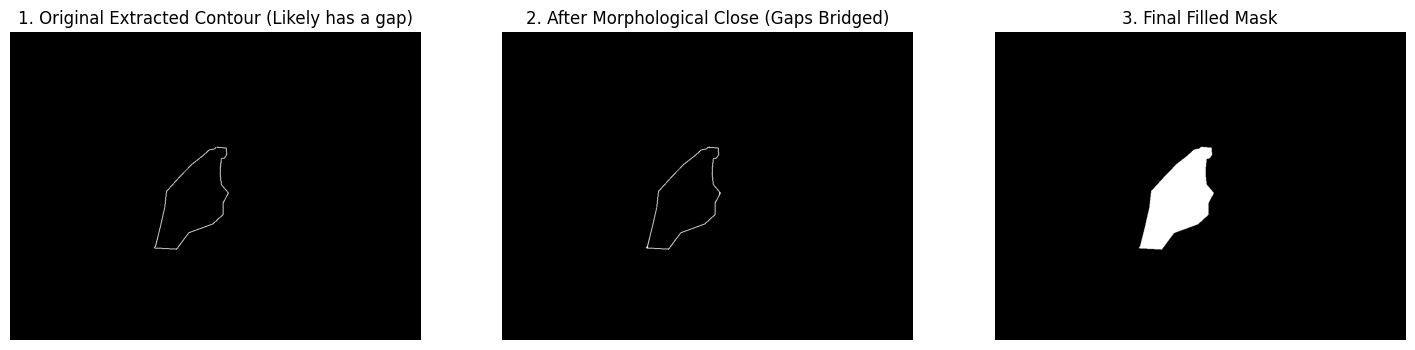

In [ ]:
import os
import pydicom
import numpy as np
import cv2
import matplotlib.pyplot as plt

# 1. Target the problematic image directly
test_directory = os.path.join("..", "data", "PANCREAS_2", "PANCREAS_2", "10_01")
date_folders = [f for f in os.listdir(test_directory) if not f.startswith(".")]
date_path = os.path.join(test_directory, date_folders[0])
valid_files = [f for f in os.listdir(date_path) if not f.startswith(".")]
file_path = os.path.join(date_path, valid_files[0])

# 2. Extract Contour (Same as before)
dataset = pydicom.dcmread(file_path)
image_rgb = dataset.pixel_array
color_threshold = 230

white_mask = (image_rgb[:, :, 0] > color_threshold) & \
             (image_rgb[:, :, 1] > color_threshold) & \
             (image_rgb[:, :, 2] > color_threshold)
white_mask_8bit = (white_mask * 255).astype(np.uint8)

num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(white_mask_8bit, connectivity=8)
largest_label = 1
max_area = 0
for i in range(1, num_labels):
    area = stats[i, cv2.CC_STAT_AREA]
    if area > max_area:
        max_area = area
        largest_label = i
        
clean_contour_mask = np.zeros_like(white_mask_8bit)
clean_contour_mask[labels == largest_label] = 255

# --- THE INVESTIGATION: MORPHOLOGICAL CLOSING ---
# We define a 5x5 pixel "brush" (kernel)
kernel = np.ones((5, 5), np.uint8)

# We close the gaps: Dilate then Erode
closed_contour_mask = cv2.morphologyEx(clean_contour_mask, cv2.MORPH_CLOSE, kernel)

# --- ATTEMPT TO FILL ---
contours, _ = cv2.findContours(closed_contour_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
filled_mask = np.zeros_like(closed_contour_mask)
cv2.drawContours(filled_mask, contours, -1, color=255, thickness=cv2.FILLED)

# --- VISUALIZE THE DIFFERENCE ---
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(clean_contour_mask, cmap="gray")
plt.title("1. Original Extracted Contour (Likely has a gap)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(closed_contour_mask, cmap="gray")
plt.title("2. After Morphological Close (Gaps Bridged)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(filled_mask, cmap="gray")
plt.title("3. Final Filled Mask")
plt.axis("off")

plt.show()

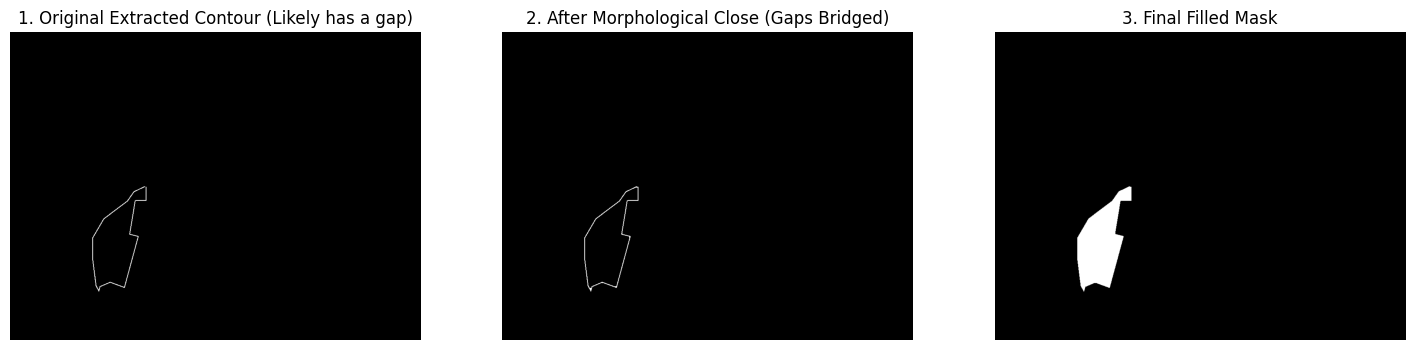

In [63]:
import os
import pydicom
import numpy as np
import cv2
import matplotlib.pyplot as plt

# 1. Target the problematic image directly
test_directory = os.path.join("..", "data", "PANCREAS_2", "PANCREAS_2", "46_03")
date_folders = [f for f in os.listdir(test_directory) if not f.startswith(".")]
date_path = os.path.join(test_directory, date_folders[0])
valid_files = [f for f in os.listdir(date_path) if not f.startswith(".")]
file_path = os.path.join(date_path, valid_files[0])

# 2. Extract Contour (Same as before)
dataset = pydicom.dcmread(file_path)
image_rgb = dataset.pixel_array
color_threshold = 230

white_mask = (image_rgb[:, :, 0] > color_threshold) & \
             (image_rgb[:, :, 1] > color_threshold) & \
             (image_rgb[:, :, 2] > color_threshold)
white_mask_8bit = (white_mask * 255).astype(np.uint8)

num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(white_mask_8bit, connectivity=8)
largest_label = 1
max_area = 0
for i in range(1, num_labels):
    area = stats[i, cv2.CC_STAT_AREA]
    if area > max_area:
        max_area = area
        largest_label = i
        
clean_contour_mask = np.zeros_like(white_mask_8bit)
clean_contour_mask[labels == largest_label] = 255

# --- THE INVESTIGATION: MORPHOLOGICAL CLOSING ---
# We define a 5x5 pixel "brush" (kernel)
kernel = np.ones((5, 5), np.uint8)

# We close the gaps: Dilate then Erode
closed_contour_mask = cv2.morphologyEx(clean_contour_mask, cv2.MORPH_CLOSE, kernel)

# --- ATTEMPT TO FILL ---
contours, _ = cv2.findContours(closed_contour_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
filled_mask = np.zeros_like(closed_contour_mask)
cv2.drawContours(filled_mask, contours, -1, color=255, thickness=cv2.FILLED)

# --- VISUALIZE THE DIFFERENCE ---
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(clean_contour_mask, cmap="gray")
plt.title("1. Original Extracted Contour (Likely has a gap)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(closed_contour_mask, cmap="gray")
plt.title("2. After Morphological Close (Gaps Bridged)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(filled_mask, cmap="gray")
plt.title("3. Final Filled Mask")
plt.axis("off")

plt.show()